In [1]:
"""
@
Auteurs:        Jeffrey Jason Boekstaaf, Tim Paulus van Croimvort en Haydar Eryörük
Studentnummers: 500460365, 500916516 en 500910901
Datum:          16-03-2026
Vak:            Beroepsproject 3.4
Opleiding:      Toegepaste Wiskunde & Data Science
School:         Hogeschool van Amsterdam
"""

import csv
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay, f1_score, precision_score, recall_score, RocCurveDisplay

# De data waarop getraind wordt.
data = pd.read_csv("data_train.csv", sep = ',')


In [2]:
# De churn wordt uit de traindata gelaten.
train = data.drop(columns = ['Churn'])
Y = data['Churn']


In [3]:
# Uit de gridsearch zijn deze parameters als de beste samenstelling gekomen en daarom dienen zij hier meegegeven te worden.
model_GB = GradientBoostingClassifier(n_estimators = 2000, learning_rate = 0.1, max_depth = 10, random_state = 0).fit(train, Y)


In [4]:
# Hier wordt het voorspellen op de validatiedata gedaan.
predicted = model_GB.predict(train)


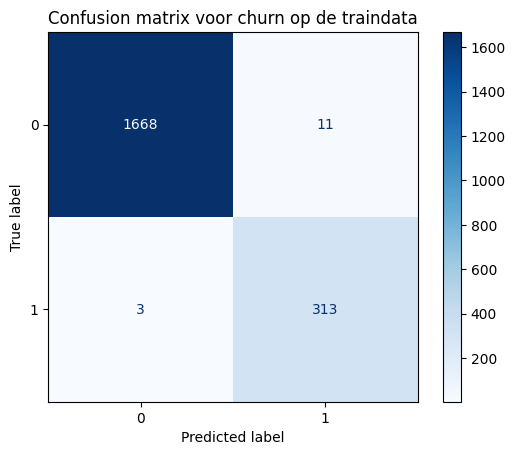

In [5]:
# Confusion matrix
ConfusionMatrixDisplay.from_predictions(Y, predicted, cmap = 'Blues')
plt.title("Confusion matrix voor churn op de traindata")
plt.show()


Hierboven is er te zien dat er (11 + 3) 14 miskwalificaties zijn. 11 klanten zijn voorspeld door dit model dat diegenen willen overstappen, terwijl diegenen dat niet hebben gedaan. 3 klanten zijn voorspeld door dit model dat dienegen niet willen overstappen, terwijl zij wel zijn overgestapd.
De andere klanten zijn wel goed voorspeld en daarvan zijn 313 die wel voorspeld zijn om over te stappen en zijn overgestapt. Deze groep is de een na grootste groep. De grootste groep zijn 1.668 klanten die niet zijn overgestapt en zijn voorspeld door het model dat diegenen ook niet willen overstappen.


In [6]:
# Hier worden de accuracy, f1, precision en recall scores berekend en gegeven.
acc = round(accuracy_score(Y, predicted), 2)
rec = round(recall_score(Y, predicted), 2)
pre = round(precision_score(Y, predicted), 2)
fsco = round(f1_score(Y, predicted), 2)
table = {"Name": ["Accuracy", "Recall", "Precision", "F1-score"],
        "Value": [acc, rec, pre, fsco]}
df = pd.DataFrame(table)
df


,Name,Value
0,Accuracy,0.99
1,Recall,0.99
2,Precision,0.97
3,F1-score,0.98


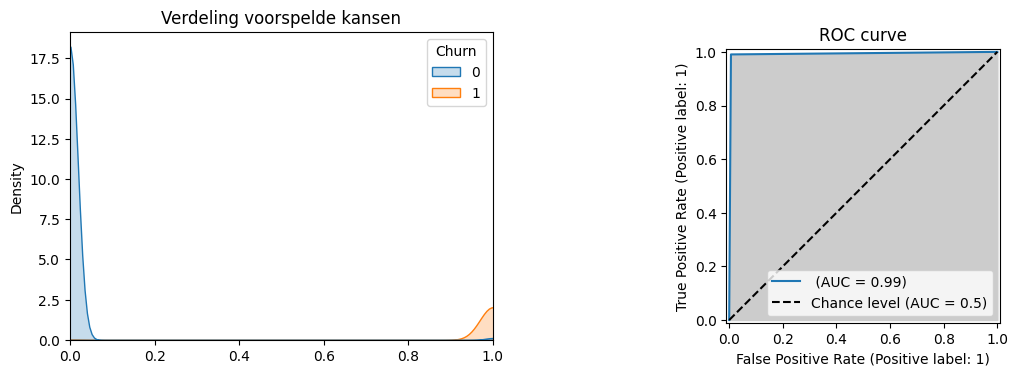

In [7]:
# Verdeling van de voorspelde kansen.
plt.figure(figsize = (12, 4))
plt.subplot(1, 2, 1)
sns.kdeplot(data = pd.DataFrame(Y), x = predicted[:], hue = 'Churn', fill = True)
plt.xlim(0, 1)
plt.title('Verdeling voorspelde kansen')

# ROC-curve
ax = plt.subplot(1, 3, 3)
roc = RocCurveDisplay.from_predictions(
    Y, 
    predicted[:], 
    name = '', 
    plot_chance_level = True,
    ax = ax)
plt.fill_between(roc.fpr, roc.tpr, color = '0.8')
plt.title('ROC curve')
plt.show()


In de figuur hierboven zijn 2 plots weergegeven, waarbij bij de eerste plot de verdeling van de voorspelde kansen voor churn weergeeft en de laatste plot een weergave is van de ROC-curve.
Hierbij geldt voor de eerste plot dat voor een waarde van Churn is 0 geldt dat het model voorspelt dat de klant het abonnement wil opzeggen en voor een waarde van Churn 1 de klant het abonnement wil opgezeggen.